# Oral Microbiome Precision Therapeutics

This notebook analyzes oral microbiome abundance data and uses machine learning to prioritize drug-like compounds from a synthetic oral drug library.

**Main goals**
1. Clean and summarize oral microbiome species abundance data.
2. Identify the most abundant bacterial species as a potential therapeutic target.
3. Train multiple machine learning models to classify drug candidates.
4. Compare model performance with repeated train/test splits and 95% confidence intervals.
5. Rank the top candidate compounds for downstream experimental screening.



In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Cell 1: Install and Import Required Libraries

This cell imports data handling, visualization, and machine learning libraries used throughout the notebook.

In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Cell 2: Set File Paths

Update these paths depending on where your Excel files are stored.

Expected input files:
- `abundance_table_species - kraken 10.xlsx`
- `Oral_Drug_Library_5000_Samples.xlsx`

In [3]:
MICROBIOME_PATH = Path("/content/drive/MyDrive/abundance_table_species - kraken 10.xlsx")
DRUG_LIBRARY_PATH = Path("/content/drive/MyDrive/Oral_Drug_Library_5000_Samples.xlsx")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Cell 3: Load the Microbiome and Drug Datasets

This section reads the oral microbiome abundance table and the drug feature library.

In [4]:
microbiome_raw = pd.read_excel(MICROBIOME_PATH)
drugs_raw = pd.read_excel(DRUG_LIBRARY_PATH)

print("Microbiome shape:", microbiome_raw.shape)
print("Drug library shape:", drugs_raw.shape)

display(microbiome_raw.head())
display(drugs_raw.head())

Microbiome shape: (388, 16)
Drug library shape: (5000, 8)


,tax,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,barcode01,barcode02,barcode03,barcode04,barcode05,barcode07,barcode08,total
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,106181,88673,19,97356,100878,24176,107940,525223
1,Bacteria,Bacteria_none,Pseudomonadota,Gammaproteobacteria,Pasteurellales,Pasteurellaceae,Haemophilus,Haemophilus parainfluenzae,22947,37648,19,14633,34161,7693,16655,133756
2,Bacteria,Bacteria_none,Pseudomonadota,Betaproteobacteria,Neisseriales,Neisseriaceae,Neisseria,Neisseria flavescens,112,83,0,21758,97,674,1399,24123
3,Bacteria,Bacteria_none,Pseudomonadota,Betaproteobacteria,Neisseriales,Neisseriaceae,Neisseria,Neisseria perflava,1088,723,0,9412,273,0,10457,21953
4,Bacteria,Bacteria_none,Bacillota,Negativicutes,Veillonellales,Veillonellaceae,Veillonella,Veillonella atypica,7390,3191,0,304,8622,145,341,19993


,SampleName,Solubility_mgL,Permeability_Papp_x1e-6,Bioavailability_pct,pKa,MolecularMass_Da,Polarity_TPSA_proxy,Category
0,OBHB7ZHE02876,998.709999,7.002032,11.697261,6.449081,241.441308,46.582801,4
1,OB05ZHI603944,996.313172,21.248753,91.972493,8.693384,657.303121,158.359206,4
2,OB24W7W802712,995.102373,1.023556,8.133318,5.853753,488.762602,115.927792,3
3,OBUP229E03540,994.550782,21.610293,77.785501,11.413981,556.124316,88.442696,4
4,OBYU2RNA02770,993.381331,20.585048,88.937300,3.585562,848.476806,82.169435,4


## Cell 4: Clean the Oral Microbiome Taxonomy Table

The original microbiome table uses unnamed columns for taxonomy levels. This cell renames those columns and converts sample read counts to numeric values.

In [5]:
taxonomy_columns = {
    "tax": "Kingdom",
    "Unnamed: 1": "Subgroup",
    "Unnamed: 2": "Phylum",
    "Unnamed: 3": "Class",
    "Unnamed: 4": "Order",
    "Unnamed: 5": "Family",
    "Unnamed: 6": "Genus",
    "Unnamed: 7": "Species",
}

sample_cols = [
    "barcode01",
    "barcode02",
    "barcode03",
    "barcode04",
    "barcode05",
    "barcode07",
    "barcode08",
]

microbiome = microbiome_raw.rename(columns=taxonomy_columns).copy()

# Keep rows with species names.
microbiome = microbiome.dropna(subset=["Species"]).copy()

# Convert sample columns to numeric read counts.
for col in sample_cols:
    microbiome[col] = pd.to_numeric(microbiome[col], errors="coerce").fillna(0)

display(microbiome.head())

,Kingdom,Subgroup,Phylum,Class,Order,Family,Genus,Species,barcode01,barcode02,barcode03,barcode04,barcode05,barcode07,barcode08,total
1,Bacteria,Bacteria_none,Pseudomonadota,Gammaproteobacteria,Pasteurellales,Pasteurellaceae,Haemophilus,Haemophilus parainfluenzae,22947,37648,19,14633,34161,7693,16655,133756
2,Bacteria,Bacteria_none,Pseudomonadota,Betaproteobacteria,Neisseriales,Neisseriaceae,Neisseria,Neisseria flavescens,112,83,0,21758,97,674,1399,24123
3,Bacteria,Bacteria_none,Pseudomonadota,Betaproteobacteria,Neisseriales,Neisseriaceae,Neisseria,Neisseria perflava,1088,723,0,9412,273,0,10457,21953
4,Bacteria,Bacteria_none,Bacillota,Negativicutes,Veillonellales,Veillonellaceae,Veillonella,Veillonella atypica,7390,3191,0,304,8622,145,341,19993
5,Bacteria,Bacteria_none,Bacillota,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus,Streptococcus oralis,13230,331,0,1519,930,324,402,16736


## Cell 5: Summarize Species Abundance Across Samples

This creates a species-level summary table with total reads, mean reads, maximum reads, and the number of samples where each species was detected.

In [6]:
species_summary = microbiome.groupby("Species")[sample_cols].sum()

species_summary["Mean_Reads"] = species_summary[sample_cols].mean(axis=1)
species_summary["Max_Reads"] = species_summary[sample_cols].max(axis=1)
species_summary["Total_Reads"] = species_summary[sample_cols].sum(axis=1)
species_summary["Samples_Present"] = (species_summary[sample_cols] > 0).sum(axis=1)

species_summary = species_summary.sort_values("Total_Reads", ascending=False)

top_25_species = species_summary.head(25)
display(top_25_species)

top_25_species.to_csv(OUTPUT_DIR / "top_25_oral_microbiome_species.csv")

,barcode01,barcode02,barcode03,barcode04,barcode05,barcode07,barcode08,Mean_Reads,Max_Reads,Total_Reads,Samples_Present
Species,,,,,,,,,,,
Haemophilus parainfluenzae,22947,37648,19,14633,34161,7693,16655,19108.000000,37648,133756,7
Neisseria flavescens,112,83,0,21758,97,674,1399,3446.142857,21758,24123,6
Neisseria perflava,1088,723,0,9412,273,0,10457,3136.142857,10457,21953,5
Veillonella atypica,7390,3191,0,304,8622,145,341,2856.142857,8622,19993,6
Streptococcus oralis,13230,331,0,1519,930,324,402,2390.857143,13230,16736,6
Streptococcus infantis,1608,2946,0,1787,1251,1366,2413,1624.428571,2946,11371,6
Campylobacter concisus,4402,947,0,817,3621,279,227,1470.428571,4402,10293,6
Streptococcus koreensis,1312,2538,0,645,582,290,3925,1327.428571,3925,9292,6
Veillonella parvula,3049,1924,0,28,3139,167,643,1278.571429,3139,8950,6


## Cell 6: Plot the Top 25 Most Abundant Oral Microbiome Species

This graph shows which bacterial species dominate the oral microbiome samples.

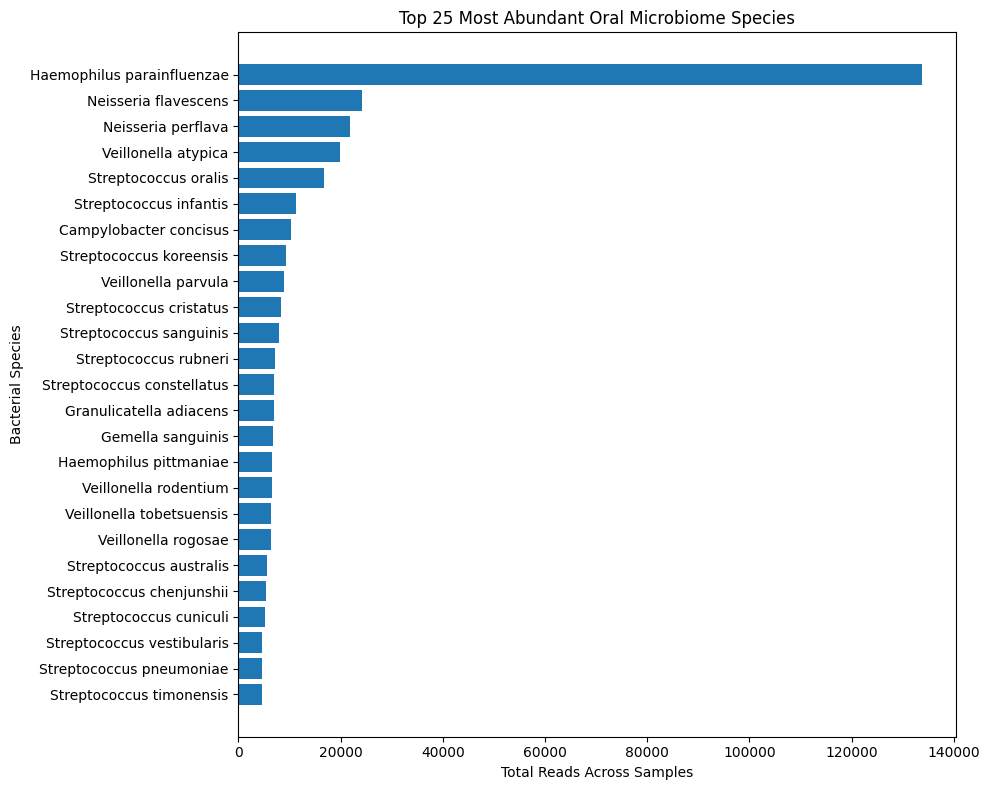

In [7]:
plt.figure(figsize=(10, 8))
plt.barh(top_25_species.index, top_25_species["Total_Reads"])
plt.gca().invert_yaxis()
plt.xlabel("Total Reads Across Samples")
plt.ylabel("Bacterial Species")
plt.title("Top 25 Most Abundant Oral Microbiome Species")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_25_species_abundance.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell 7: Select a Candidate Bacterial Target

For this project, the highest-abundance species is selected as a simple target-prioritization example. A stronger biological analysis would also include literature review, pathogenic relevance, patient metadata, and oral health context.

In [8]:
selected_target = species_summary.index[0]
target_total_reads = species_summary.iloc[0]["Total_Reads"]
target_samples_present = species_summary.iloc[0]["Samples_Present"]

print(f"Selected bacterial target: {selected_target}")
print(f"Total reads: {target_total_reads:,.0f}")
print(f"Samples present: {target_samples_present} out of {len(sample_cols)}")

Selected bacterial target: Haemophilus parainfluenzae
Total reads: 133,756
Samples present: 7.0 out of 7


## Cell 8: Clean the Drug Library

This section keeps the physicochemical drug features and target category used for supervised classification.

In [9]:
drugs = drugs_raw.dropna().copy()

feature_cols = [
    "Solubility_mgL",
    "Permeability_Papp_x1e-6",
    "Bioavailability_pct",
    "pKa",
    "MolecularMass_Da",
    "Polarity_TPSA_proxy",
]

target_col = "Category"

X = drugs[feature_cols]
y = drugs[target_col]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
display(y.value_counts().sort_index())

Feature matrix shape: (5000, 6)
Target distribution:


,count
Category,
1,1250
2,1250
3,1250
4,1250


## Cell 9: Train/Test Split

A stratified split keeps the class distribution balanced between the training and test sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


## Cell 10: Define Candidate Machine Learning Models

Models that depend on feature scale, such as Logistic Regression, KNN, and SVM, are placed inside a pipeline with `StandardScaler`.

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7)),
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=RANDOM_STATE)),
    ]),
}

## Cell 11: Train and Evaluate Each Model Once

This gives an initial performance comparison using the same train/test split.

In [12]:
single_split_results = []

for name, model in models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    single_split_results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
    })

    print("=" * 80)
    print(name)
    print(f"Accuracy: {acc:.3f}")
    print(f"Macro F1: {macro_f1:.3f}")
    print()
    print(classification_report(y_test, y_pred))

single_split_df = pd.DataFrame(single_split_results).sort_values("Accuracy", ascending=False)
display(single_split_df)

single_split_df.to_csv(OUTPUT_DIR / "single_split_model_results.csv", index=False)

Logistic Regression
Accuracy: 0.506
Macro F1: 0.490

              precision    recall  f1-score   support

           1       0.56      0.76      0.65       250
           2       0.40      0.32      0.35       250
           3       0.39      0.30      0.34       250
           4       0.59      0.64      0.62       250

    accuracy                           0.51      1000
   macro avg       0.49      0.51      0.49      1000
weighted avg       0.49      0.51      0.49      1000

Decision Tree
Accuracy: 0.512
Macro F1: 0.503

              precision    recall  f1-score   support

           1       0.65      0.69      0.67       250
           2       0.38      0.44      0.41       250
           3       0.40      0.27      0.32       250
           4       0.58      0.65      0.62       250

    accuracy                           0.51      1000
   macro avg       0.50      0.51      0.50      1000
weighted avg       0.50      0.51      0.50      1000

Random Forest
Accuracy: 0.778


,Model,Accuracy,Macro_F1
2,Random Forest,0.778,0.777499
3,Gradient Boosting,0.746,0.743879
4,KNN,0.699,0.696478
5,SVM,0.689,0.690557
1,Decision Tree,0.512,0.503465
0,Logistic Regression,0.506,0.490028


## Cell 12: Plot Confusion Matrices for the Best Models

The confusion matrix shows which drug categories are predicted correctly and which categories are commonly confused.

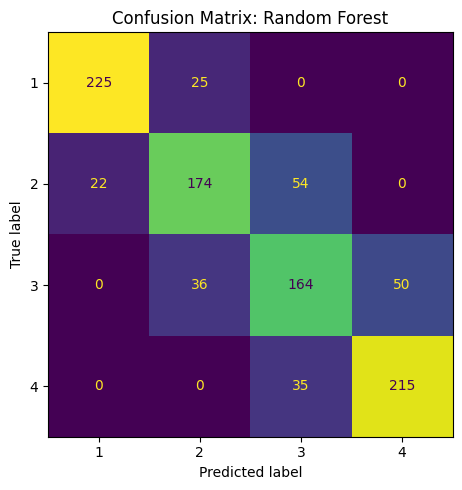

Best model: Random Forest


In [13]:
best_model_name = single_split_df.iloc[0]["Model"]
best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    ax=ax,
    cmap=None,
    colorbar=False,
)
ax.set_title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Best model:", best_model_name)

## Cell 13: Repeated Model Evaluation for Confidence Intervals

A single train/test split can be noisy. This section repeats stratified train/test splitting multiple times and records model performance across splits.

The result is a more reliable model comparison using mean accuracy and a 95% confidence interval.

In [14]:
n_splits = 30

splitter = StratifiedShuffleSplit(
    n_splits=n_splits,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

repeated_results = []

for split_id, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    for model_name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_tr, y_tr)
        y_pred = fitted_model.predict(X_te)

        repeated_results.append({
            "Split": split_id,
            "Model": model_name,
            "Accuracy": accuracy_score(y_te, y_pred),
            "Macro_F1": f1_score(y_te, y_pred, average="macro"),
            "Weighted_F1": f1_score(y_te, y_pred, average="weighted"),
        })

repeated_results_df = pd.DataFrame(repeated_results)
display(repeated_results_df.head())

repeated_results_df.to_csv(OUTPUT_DIR / "repeated_split_model_results.csv", index=False)

,Split,Model,Accuracy,Macro_F1,Weighted_F1
0,1,Logistic Regression,0.506,0.490028,0.490028
1,1,Decision Tree,0.512,0.503465,0.503465
2,1,Random Forest,0.778,0.777499,0.777499
3,1,Gradient Boosting,0.746,0.743879,0.743879
4,1,KNN,0.699,0.696478,0.696478


## Cell 14: Summarize Repeated Model Performance

This table reports mean performance and the 95% confidence interval for each model.

In [15]:
def summarize_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    summary = (
        df.groupby("Model")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["sem"] = summary["std"] / np.sqrt(summary["count"])
    summary["ci95"] = 1.96 * summary["sem"]
    summary = summary.sort_values("mean", ascending=False)
    return summary

accuracy_summary = summarize_metric(repeated_results_df, "Accuracy")
macro_f1_summary = summarize_metric(repeated_results_df, "Macro_F1")

display(accuracy_summary)
accuracy_summary.to_csv(OUTPUT_DIR / "accuracy_summary_with_ci.csv", index=False)

,Model,mean,std,count,sem,ci95
4,Random Forest,0.764567,0.015769,30,0.002879,0.005643
1,Gradient Boosting,0.764300,0.012132,30,0.002215,0.004341
2,KNN,0.702167,0.012991,30,0.002372,0.004649
5,SVM,0.681700,0.017335,30,0.003165,0.006203
0,Decision Tree,0.508867,0.009243,30,0.001688,0.003308
3,Logistic Regression,0.507033,0.011122,30,0.002031,0.003980


## Cell 15: Plot All Model Performance With a 95% Confidence Interval Band

The points show mean accuracy for each model. The transparent band shows the 95% confidence interval across repeated stratified train/test splits.

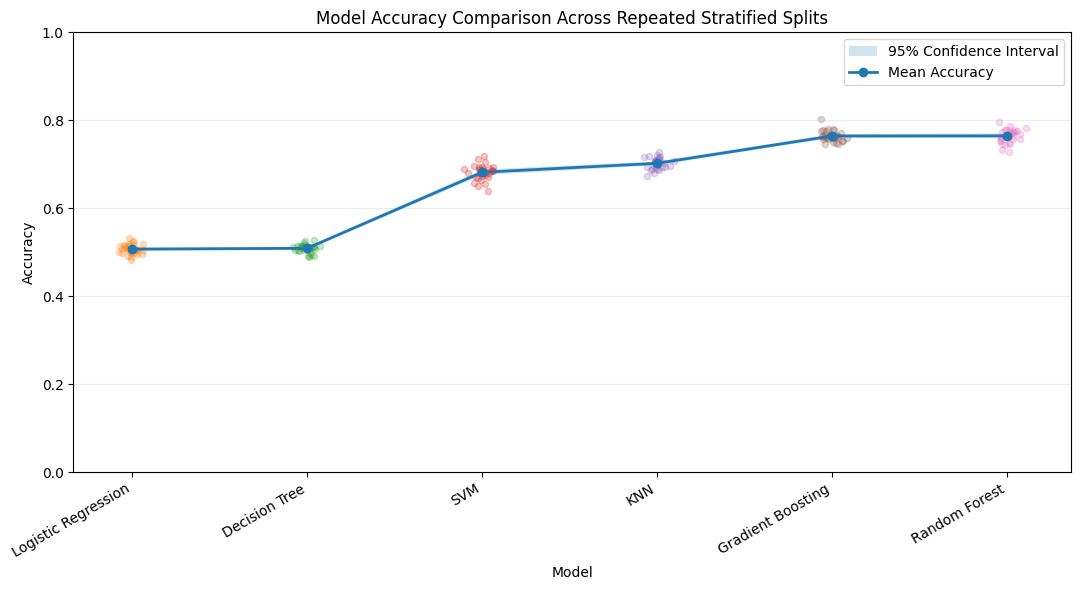

In [16]:
plot_df = accuracy_summary.copy()
plot_df = plot_df.sort_values("mean", ascending=True).reset_index(drop=True)

x = np.arange(len(plot_df))
mean_acc = plot_df["mean"].to_numpy()
ci = plot_df["ci95"].to_numpy()

plt.figure(figsize=(11, 6))

# Transparent confidence interval band
plt.fill_between(
    x,
    mean_acc - ci,
    mean_acc + ci,
    alpha=0.20,
    label="95% Confidence Interval",
)

# Mean model performance line
plt.plot(
    x,
    mean_acc,
    marker="o",
    linewidth=2,
    label="Mean Accuracy",
)

# Add individual split values as faint points
for i, model_name in enumerate(plot_df["Model"]):
    values = repeated_results_df.loc[
        repeated_results_df["Model"] == model_name,
        "Accuracy",
    ].to_numpy()

    jitter = np.random.normal(loc=0, scale=0.04, size=len(values))
    plt.scatter(
        np.full_like(values, i, dtype=float) + jitter,
        values,
        alpha=0.25,
        s=20,
    )

plt.xticks(x, plot_df["Model"], rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison Across Repeated Stratified Splits")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_accuracy_comparison_ci_band.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell 16: Train the Final Model

The best-performing model is trained on the full dataset before ranking candidate compounds.

In [17]:
final_model_name = accuracy_summary.iloc[0]["Model"]
final_model = clone(models[final_model_name])
final_model.fit(X, y)

print(f"Final selected model: {final_model_name}")

Final selected model: Random Forest


## Cell 17: Rank Candidate Compounds

This section ranks drug candidates by their predicted probability of being in the highest target category.

For this dataset, Category 4 is treated as the highest-priority candidate category.

In [18]:
priority_category = 4

drugs_ranked = drugs.copy()
drugs_ranked["Predicted_Category"] = final_model.predict(X)

if hasattr(final_model, "predict_proba"):
    probabilities = final_model.predict_proba(X)
    class_labels = list(final_model.classes_)

    if priority_category in class_labels:
        priority_index = class_labels.index(priority_category)
        drugs_ranked[f"Probability_Category_{priority_category}"] = probabilities[:, priority_index]
    else:
        raise ValueError(f"Priority category {priority_category} was not found in model classes.")
else:
    raise TypeError("The final model does not support probability predictions.")

top_100_candidates = drugs_ranked.sort_values(
    by=[f"Probability_Category_{priority_category}", "Predicted_Category"],
    ascending=False,
).head(100)

display(top_100_candidates.head(20))

top_100_candidates.to_csv(OUTPUT_DIR / "top_100_drug_candidates.csv", index=False)

,SampleName,Solubility_mgL,Permeability_Papp_x1e-6,Bioavailability_pct,pKa,MolecularMass_Da,Polarity_TPSA_proxy,Category,Predicted_Category,Probability_Category_4
1044,OBF90KM300285,236.034018,27.618590,80.658660,7.371071,393.384814,74.953752,4,4,0.998889
391,OBHCG7FD03337,591.593895,21.817216,38.796770,7.452908,303.379439,37.591464,4,4,0.998778
360,OBUG8XJK03272,615.755699,0.931906,72.333376,7.563586,350.724748,77.408472,4,4,0.998333
2601,OBFFZ8Q401129,28.495076,0.328731,88.606840,6.987367,366.224542,59.813954,4,4,0.996667
355,OBJQ7W7J00909,616.985811,4.391829,77.620323,6.996160,210.434199,84.639283,4,4,0.995167
516,OBRUTVLY03087,489.877749,0.256825,50.675565,6.748213,372.828215,84.842090,4,4,0.993889
2158,OB54696Q01442,52.707774,20.794817,82.709196,7.576244,305.856112,89.292455,4,4,0.993778
188,OBRNAMZ601608,770.516576,25.767403,73.775524,10.405255,273.516908,44.972432,4,4,0.993333
285,OBPMX76A03724,682.010888,0.891519,82.141594,6.567241,226.848470,63.822063,4,4,0.991937
310,OBBEKTJE04594,661.479800,0.994064,78.514853,7.575596,217.081987,100.062931,4,4,0.991111


## Cell 18: Feature Importance for Tree-Based Final Models

If the final model supports feature importance, this plot shows which drug features were most useful for classification.

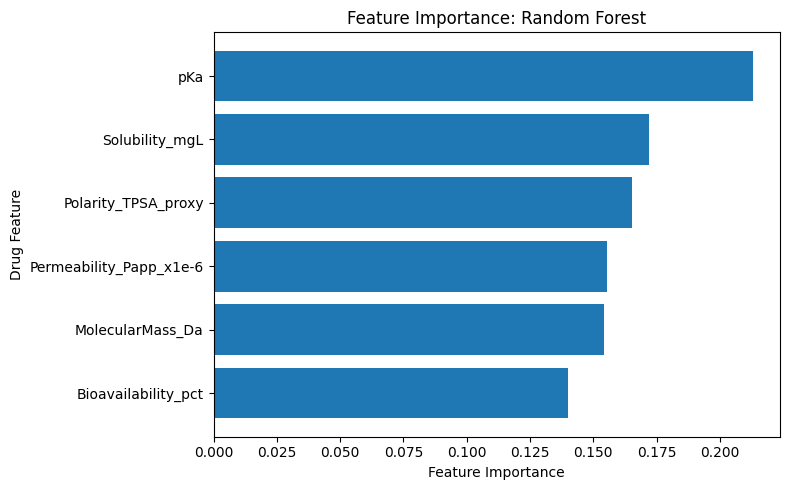

,Feature,Importance
3,pKa,0.213113
0,Solubility_mgL,0.172051
5,Polarity_TPSA_proxy,0.165241
1,Permeability_Papp_x1e-6,0.155532
4,MolecularMass_Da,0.154091
2,Bioavailability_pct,0.139971


In [19]:
if hasattr(final_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": final_model.feature_importances_,
    }).sort_values("Importance", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Drug Feature")
    plt.title(f"Feature Importance: {final_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "final_model_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

    display(importance_df.sort_values("Importance", ascending=False))
else:
    print(f"{final_model_name} does not provide built-in feature importance.")

## Cell 19: Save Final Outputs

This cell confirms the main files produced by the notebook.

In [20]:
print("Saved outputs:")
for file in sorted(OUTPUT_DIR.iterdir()):
    print("-", file)

Saved outputs:
- outputs/accuracy_summary_with_ci.csv
- outputs/best_model_confusion_matrix.png
- outputs/final_model_feature_importance.png
- outputs/model_accuracy_comparison_ci_band.png
- outputs/repeated_split_model_results.csv
- outputs/single_split_model_results.csv
- outputs/top_100_drug_candidates.csv
- outputs/top_25_oral_microbiome_species.csv
- outputs/top_25_species_abundance.png


## Cell 20: Project Summary

This notebook found the most abundant oral microbiome species in the sample set, trained several drug-category classifiers, compared model accuracy with repeated stratified splits, and produced a ranked list of top candidate compounds.

The model results should be interpreted as computational prioritization, not confirmed therapeutic effectiveness. The top-ranked candidates would still require biological validation, toxicity screening, and experimental testing.